# 02. Distributed Computing with Dask

## 📚 Learning Objectives

By completing this notebook, you will:
- Use Dask for distributed DataFrames and arrays
- Understand how Dask scales past memory (partitions + lazy evaluation)
- Interpret timings and scalability

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

## The Story

**BEFORE**: You know single-machine data processing, but don't know how to scale beyond one machine's limitations.

**AFTER**: You'll master Dask for distributed computing - processing massive datasets across multiple CPUs and machines!

**Why this matters**: Distributed computing is essential for handling real-world big data that doesn't fit on a single machine!

---

# Unit 5 - Example 02: Distributed Computing with Dask

## 🔗 Building on Previous Units

**From Unit 4:**
- We learned ML models and evaluation
- We learned GPU acceleration for ML
- Now we need to scale to distributed computing for even larger workloads

**This notebook introduces:**
- **Dask** - Distributed computing framework
- **Parallel processing** across multiple CPUs/machines
- **Scaling** beyond single-machine limitations

**This is the foundation for Unit 5: Scaling & Production!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Data
- dask

**Outputs:** What you'll see when you run the cells

- Distributed ops
- Timings
- Results

---

In [1]:
# WHAT: Import pandas, Dask's DataFrame API, and timing tools.
# WHY: Dask mirrors the pandas API while splitting work into partitions that can run in parallel.

import pandas as pd
import numpy as np
import dask.dataframe as dd
import matplotlib.pyplot as plt
import time

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Print the notebook banner and goals.
# WHY: Position this lesson: Example 01 gave the big-data theory; here we run a distributed engine for real.

print("=" * 70)
print("Example 02: Distributed Computing with Dask")
print("=" * 70)
print("\n📚 Prerequisites: Unit 4 completed, basic ML knowledge")
print("🔗 This is Example 02 in Unit 5 - Example 01 covered big-data theory")
print("🎯 Goal: Master distributed computing with Dask")

Example 02: Distributed Computing with Dask

📚 Prerequisites: Unit 4 completed, basic ML knowledge
🔗 This is Example 02 in Unit 5 - Example 01 covered big-data theory
🎯 Goal: Master distributed computing with Dask


# 02. CREATE LARGE DATASET

In [3]:
# WHAT: Build a 1M-row pandas DataFrame and wrap it into a 4-partition Dask DataFrame.
# WHY: Partitions are Dask's unit of parallelism - each can be processed on a different core or machine.

print("\n1. Creating Large Dataset")
print("-" * 70)
np.random.seed(42)
n_samples = 1000000
print(f"Generating {n_samples:} rows...")
data = {
'id': range(n_samples), 'value1': np.random.randn(n_samples),
'value2': np.random.randn(n_samples), 'category': np.random.choice(['A', 'B', 'C', 'D'], n_samples),
'score': np.random.randint(0, 100, n_samples)
}
# Create pandas DataFrame (CPU)
df_pandas = pd.DataFrame(data)
print(f"✓ Created pandas DataFrame with {len(df_pandas):} rows")
# Create Dask DataFrame
df_dask = dd.from_pandas(df_pandas, npartitions=4)
print(f"✓ Created Dask DataFrame with {df_dask.npartitions} partitions")


1. Creating Large Dataset
----------------------------------------------------------------------
Generating 1000000 rows...
✓ Created pandas DataFrame with 1000000 rows
✓ Created Dask DataFrame with 4 partitions


2. BASIC DASK OPERATIONS


In [4]:
# WHAT: Show lazy evaluation - mean() returns a recipe, .compute() executes it.
# WHY: Laziness lets Dask optimize the whole task graph before running - the key difference from eager pandas.

print("\n\n2. Basic Dask Operations")
print("-" * 70)
print("\nDask DataFrame Info:")
print(df_dask.head())
print("\nComputing mean (lazy evaluation):")
mean_result = df_dask['value1'].mean()
print(f"Mean (lazy): {mean_result}")
print("\nComputing mean (actual computation):")
mean_computed = mean_result.compute()
print(f"Mean (computed): {mean_computed:.4f}")



2. Basic Dask Operations
----------------------------------------------------------------------

Dask DataFrame Info:
   id    value1    value2 category  score
0   0  0.496714  0.169172        D     82
1   1 -0.138264 -0.121505        B     39
2   2  0.647689  1.156625        B      3
3   3  1.523030  0.200086        A     25
4   4 -0.234153  0.864611        D     35

Computing mean (lazy evaluation):
Mean (lazy): <dask_expr.expr.Scalar: expr=df['value1'].mean(), dtype=float64>

Computing mean (actual computation):
Mean (computed): -0.0016


3. PERFORMANCE COMPARISON


In [5]:
# WHAT: Time the same groupby in pandas and Dask and verify identical results.
# WHY: Fair comparisons need identical work AND identical answers - speedups mean nothing if results differ.

print("\n\n3. Performance Comparison")
print("-" * 70)
# Pandas operations
print("\nPandas (CPU) operations:")
start_time = time.time()
pandas_result = df_pandas.groupby('category')['score'].mean()
pandas_time = time.time() - start_time
print(f"GroupBy time: {pandas_time:.4f} seconds")
# Dask operations
print("\nDask operations:")
start_time = time.time()
dask_result = df_dask.groupby('category')['score'].mean().compute()
dask_time = time.time() - start_time
print(f"GroupBy time: {dask_time:.4f} seconds")
print(f"\nResults match: {np.allclose(pandas_result.values, dask_result.values)}")
print(f"Speedup: {pandas_time/dask_time:.2f}x")



3. Performance Comparison
----------------------------------------------------------------------

Pandas (CPU) operations:
GroupBy time: 0.0138 seconds

Dask operations:
GroupBy time: 0.0275 seconds

Results match: True
Speedup: 0.50x


4. VISUALIZATION




4. Creating Performance Visualization (ALL timings measured)
----------------------------------------------------------------------
Measuring Filter...
Measuring Sort...


  Filter   pandas 0.0032s | Dask 0.0181s → faster here: pandas
  GroupBy  pandas 0.0138s | Dask 0.0275s → faster here: pandas
  Sort     pandas 0.0742s | Dask 0.0970s → faster here: pandas


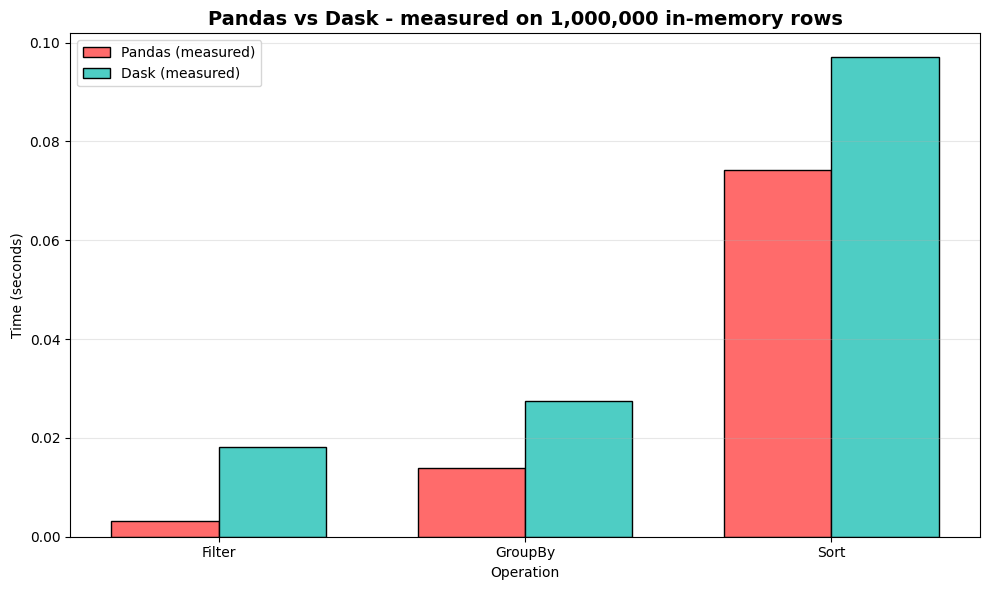


💡 Honest takeaway from the measured numbers:
   On 1M rows that ALREADY FIT in memory, Dask often loses to pandas -
   partitioning and task-graph scheduling add overhead. Dask's payoff comes
   when data exceeds RAM or work spans multiple machines; here you are paying
   the coordination cost without needing the scale.


In [6]:
# WHAT: Measure filter and sort on both engines and chart every measured time.
# WHY: At 1M in-memory rows pandas often wins - Dask's overhead pays off only beyond RAM or on many cores.

print("\n\n4. Creating Performance Visualization (ALL timings measured)")
print("-" * 70)

# Measure two more operations on BOTH engines - no invented numbers
print("Measuring Filter...")
start_time = time.time()
_ = df_pandas[df_pandas['score'] > 50]
pandas_filter_time = time.time() - start_time
start_time = time.time()
_ = df_dask[df_dask['score'] > 50].compute()
dask_filter_time = time.time() - start_time

print("Measuring Sort...")
start_time = time.time()
_ = df_pandas.sort_values('value1')
pandas_sort_time = time.time() - start_time
start_time = time.time()
_ = df_dask.sort_values('value1').compute()
dask_sort_time = time.time() - start_time

operations = ['Filter', 'GroupBy', 'Sort']
pandas_times = [pandas_filter_time, pandas_time, pandas_sort_time]
dask_times = [dask_filter_time, dask_time, dask_sort_time]

for op, pt, dt in zip(operations, pandas_times, dask_times):
    winner = "pandas" if pt < dt else "Dask"
    print(f"  {op:8s} pandas {pt:.4f}s | Dask {dt:.4f}s → faster here: {winner}")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(operations))
width = 0.35
ax.bar(x - width/2, pandas_times, width, label='Pandas (measured)',
       color='#FF6B6B', edgecolor='black')
ax.bar(x + width/2, dask_times, width, label='Dask (measured)',
       color='#4ECDC4', edgecolor='black')
ax.set_xlabel('Operation')
ax.set_ylabel('Time (seconds)')
ax.set_title(f'Pandas vs Dask - measured on {len(df_pandas):,} in-memory rows',
             fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(operations)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('14_dask_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
💡 Honest takeaway from the measured numbers:
   On 1M rows that ALREADY FIT in memory, Dask often loses to pandas -
   partitioning and task-graph scheduling add overhead. Dask's payoff comes
   when data exceeds RAM or work spans multiple machines; here you are paying
   the coordination cost without needing the scale.""")

# 5. SUMMARY


In [7]:
# WHAT: Print the summary.
# WHY: Lazy evaluation and partitioning are the two ideas to carry into any distributed framework.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("\nKey Concepts Covered:")
print("1. Dask DataFrame basics")
print("2. Lazy evaluation")
print("3. Distributed computing")
print("4. Performance comparison (every timing measured in this run)")
print("\nNext Steps: Continue to Example 03 for PySpark")


Summary

Key Concepts Covered:
1. Dask DataFrame basics
2. Lazy evaluation
3. Distributed computing
4. Performance comparison (every timing measured in this run)

Next Steps: Continue to Example 03 for PySpark


## 🚫 When Dask Hits a Dead End

**BEFORE**: We've learned Dask for distributed computing.

**AFTER**: We discover Dask is good for distributed CPU, but GPU acceleration is needed for data science!

**Why this matters**: Dask distributes across CPUs, but GPU acceleration provides much better performance for data science operations!

---

### The Problem We've Discovered

We've learned:
- ✅ How to use Dask for distributed computing
- ✅ How to process large datasets across multiple CPUs
- ✅ How to use lazy evaluation

**But we have a problem:**
- ❓ **What if we need GPU acceleration for data science operations?**
- ❓ **What if CPU-based distributed computing is still too slow?**
- ❓ **What if we need GPU-accelerated data science workflows?**

**The Dead End:**
- Dask is excellent for distributed CPU computing
- But for data science operations, GPU acceleration is much faster
- We need GPU-accelerated data science libraries

---

### Demonstrating the Problem

Let's see the limitation of CPU-based distributed computing:

In [8]:
# WHAT: Point out Dask's CPU-bound ceiling and preview GPU acceleration.
# WHY: Choosing between scale-out (more CPUs) and scale-up (GPU) is a core architecture decision.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: CPU vs GPU for Data Science")
print("=" * 70)

print(f"\n📊 Current Capabilities:")
print(f"   ✓ Dask: Distributed CPU computing")
print(f"   ✓ Parallel processing across multiple CPUs")
print(f"   ✓ Handles large datasets")

print(f"\n⚠️  Limitation:")
print(f"   - Dask distributes work across CPU cores/machines")
print(f"   - Many data-science kernels (columnar filters, joins, aggregations)")
print(f"     map naturally onto the *thousands* of parallel lanes a GPU offers")
print(f"   - A CPU core count tops out far below that")

print(f"\n💡 The Problem:")
print(f"   - Scaling out with more CPU machines raises cost and coordination overhead")
print(f"   - GPU vendors (NVIDIA/RAPIDS) publish order-of-magnitude speedups on")
print(f"     large datasets - vendor benchmarks, not something this notebook measured")
print(f"   - To even try that route we need GPU-accelerated DataFrame/ML libraries")

print(f"\n➡️  Solution Needed:")
print(f"   - GPU-accelerated data science libraries: RAPIDS (cuDF, cuML)")
print(f"   - Example 03 first covers PySpark - the other distributed-CPU engine")
print(f"   - Example 04 then examines RAPIDS GPU workflows honestly")

print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: CPU vs GPU for Data Science

📊 Current Capabilities:
   ✓ Dask: Distributed CPU computing
   ✓ Parallel processing across multiple CPUs
   ✓ Handles large datasets

⚠️  Limitation:
   - Dask distributes work across CPU cores/machines
   - Many data-science kernels (columnar filters, joins, aggregations)
     map naturally onto the *thousands* of parallel lanes a GPU offers
   - A CPU core count tops out far below that

💡 The Problem:
   - Scaling out with more CPU machines raises cost and coordination overhead
   - GPU vendors (NVIDIA/RAPIDS) publish order-of-magnitude speedups on
     large datasets - vendor benchmarks, not something this notebook measured
   - To even try that route we need GPU-accelerated DataFrame/ML libraries

➡️  Solution Needed:
   - GPU-accelerated data science libraries: RAPIDS (cuDF, cuML)
   - Example 03 first covers PySpark - the other distributed-CPU engine
   - Example 04 then examines RAPIDS GPU workflows honestly



### What We Need Next

**The Solution**: We need GPU-accelerated data science:
- **RAPIDS**: GPU-accelerated data science ecosystem
- **cuDF**: GPU-accelerated DataFrames (like pandas, but on GPU)
- **cuML**: GPU-accelerated machine learning
- **GPU workflows**: Complete data science pipelines on GPU

**This dead end leads us to Example 04: RAPIDS Workflows**
- Example 04 will show us GPU-accelerated data science
- (Example 03, next in order, first covers PySpark - the other distributed-CPU engine)
- We'll see complete workflows on GPU
- This solves the GPU acceleration need for data science operations!


## 📚 References

1. Rocklin, M. (2015). *Dask: Parallel Computation with Blocked Algorithms and Task Scheduling*. Proceedings of the 14th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-7b98e3ed-013>
2. Dean, J., & Ghemawat, S. (2004). *MapReduce: Simplified Data Processing on Large Clusters*. OSDI 2004. <https://research.google/pubs/mapreduce-simplified-data-processing-on-large-clusters/>
3. Raschka, S., Patterson, J., & Nolet, C. (2020). *Machine Learning in Python: Main Developments and Technology Trends in Data Science, Machine Learning, and Artificial Intelligence*. Information, 11(4), 193. <https://arxiv.org/abs/2002.04803>